# 10 — Improved XGBoost-DART (Rolling Window + Rank Target + Monthly+20d)

Same three fixes as NB09 but using **XGBoost-DART** instead of LightGBM.

DART (Dropout Additive Regression Trees) randomly drops trees during boosting — like
dropout in neural nets — which prevents over-reliance on any single tree and adds
regularisation that helps with sparse NLP signals.

**Changes vs NB08:**
| | NB08 (Original) | NB10 (Improved) |
|---|---|---|
| Target | raw fwd_20d | cross-sectional rank of fwd_20d |
| Training | expanding from 2010 | rolling 3 years |
| Rebalance | monthly (NB08 was already monthly) | monthly |
| Features | top-50 per fold | top-20 IC-stable (same as NB09) |
| n_estimators | 200 | **100** (2× faster) |
| Tuning | grid search on 2010-2017 | **no tuning** — fixed best params |
| Refits | 24 quarterly | **6 annual** (4× fewer) |

**Expected speedup vs NB08: ~8×**

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)

PROJECT  = Path(os.getenv('ATC_PROJECT_ROOT',
                Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))
DATA_DIR = PROJECT / 'data'
FIG_DIR  = PROJECT / 'figures'

feat_df = pd.read_parquet(DATA_DIR / 'features.parquet')
feat_df['entry_date'] = pd.to_datetime(feat_df['entry_date'])

TC_BPS = 5
TC     = TC_BPS / 10_000
UNIV_LABELS = {'in_sp500': 'SP500', 'in_sp1500': 'SP1500', 'in_ru3k': 'RU3K proxy'}

SKIP_COLS = {'entry_date','BESTTICKER','DocID','SECTOR','GVKEY','Year','DocDate','QTR_YEAR',
             'in_sp500','in_sp1500','in_ru3k',
             'fwd_1d','fwd_3d','fwd_5d','fwd_10d','fwd_20d'}
ALL_FEATS = [c for c in feat_df.columns if c not in SKIP_COLS]

print(f'Loaded: {feat_df.shape},  features: {len(ALL_FEATS)}')
print(f'XGBoost version: {xgb.__version__}')

Loaded: (376790, 92),  features: 78
XGBoost version: 3.2.0


## 10.1 Reuse IC-Stable Features from NB09

We recompute the same IC-stability ranking to get the top-20 features, then add rolling_ic as in NB09.

In [2]:
# IC-stability feature selection (same as NB09)
sel_df = feat_df[feat_df['in_sp1500']].dropna(subset=['fwd_20d']).copy()
sel_df['year'] = sel_df['entry_date'].dt.year

print('Computing IC stability scores...')
ic_records = []
for yr, grp in sel_df.groupby('year'):
    if len(grp) < 100: continue
    for feat in ALL_FEATS:
        col = grp[feat].dropna()
        if len(col) < 50: continue
        ic = col.corr(grp.loc[col.index, 'fwd_20d'], method='spearman')
        ic_records.append({'year': yr, 'feature': feat, 'ic': ic})

ic_df = pd.DataFrame(ic_records)
stability = ic_df.groupby('feature')['ic'].agg(
    median_ic='median', std_ic='std'
).reset_index()
stability['stability_score'] = stability['median_ic'] / (stability['std_ic'] + 0.01)

TOP_FEATS = (stability[stability['median_ic'] > 0]
             .sort_values('stability_score', ascending=False)
             .head(20)['feature'].tolist())

# Add rolling IC feature (PIT — uses only prior months)
feat_df['month'] = feat_df['entry_date'].dt.to_period('M')
feat_df['month_num'] = feat_df['entry_date'].dt.year * 12 + feat_df['entry_date'].dt.month
feat_df = feat_df.sort_values('entry_date').reset_index(drop=True)

ric_records = []
for m in sorted(feat_df['month_num'].unique()):
    sub = feat_df[(feat_df['month_num'] >= m-12) & (feat_df['month_num'] <= m-1)]
    sub = sub.dropna(subset=['ATCClassifierScore','fwd_20d'])
    ic = sub['ATCClassifierScore'].corr(sub['fwd_20d'], method='spearman') if len(sub)>=30 else np.nan
    ric_records.append({'month_num': m, 'rolling_ic': ic})
ric_df = pd.DataFrame(ric_records)
feat_df = feat_df.merge(ric_df, on='month_num', how='left')
feat_df['rolling_ic'] = feat_df['rolling_ic'].fillna(0)

# Rank target
feat_df['rank_target'] = (
    feat_df.groupby(['SECTOR','month'])['fwd_20d']
    .transform(lambda x: x.rank(pct=True))
)

TOP_FEATS_FINAL = TOP_FEATS + ['rolling_ic']
print(f'Features: {len(TOP_FEATS_FINAL)} (top-20 stable + rolling_ic)')
print(f'Rank target coverage: {feat_df["rank_target"].notna().sum():,}')

Computing IC stability scores...


Features: 21 (top-20 stable + rolling_ic)
Rank target coverage: 160,560


## 10.2 Portfolio Simulation Helpers

In [3]:
def simulate_portfolio(df, signal_col, univ_col, rebal_freq='M', horizon=20):
    ret_col = f'fwd_{horizon}d'
    sub = df[df[univ_col]].dropna(subset=[signal_col, ret_col]).copy()
    sub['period'] = sub['entry_date'].dt.to_period(rebal_freq)
    period_returns, period_turns = [], []
    prev_long, prev_short = set(), set()
    for period, grp in sub.groupby('period'):
        if len(grp) < 20: continue
        n_pos = max(int(len(grp) * 0.1), 1)
        ranked = grp.sort_values(signal_col)
        longs  = set(ranked.tail(n_pos)['BESTTICKER'])
        shorts = set(ranked.head(n_pos)['BESTTICKER'])
        lr = grp[grp['BESTTICKER'].isin(longs)][ret_col].mean()
        sr = grp[grp['BESTTICKER'].isin(shorts)][ret_col].mean()
        if prev_long:
            long_to  = 1 - len(longs&prev_long)  / max(len(longs|prev_long),  1)
            short_to = 1 - len(shorts&prev_short) / max(len(shorts|prev_short),1)
            turnover = (long_to + short_to) / 2
        else:
            turnover = 1.0
        net_ret = (lr - sr) - 2 * turnover * TC
        period_returns.append({'period': period, 'gross_ls': lr-sr, 'net_ls': net_ret})
        period_turns.append({'period': period, 'turnover': turnover})
        prev_long, prev_short = longs, shorts
    ret_df = pd.DataFrame(period_returns).set_index('period')
    trn_df = pd.DataFrame(period_turns).set_index('period')
    return ret_df, trn_df

def sharpe(s, n_active, n_years):
    r = s.dropna()
    ppy = n_active / n_years if n_years > 0 else 12
    return r.mean() / (r.std() + 1e-9) * np.sqrt(ppy)

print('Helpers loaded.')

Helpers loaded.


## 10.3 Walk-Forward XGBoost-DART

**Fixed hyperparameters** (no grid search — saves 80% of runtime):
- `booster=dart`, `n_estimators=100`, `max_depth=4`, `learning_rate=0.05`
- `rate_drop=0.15` (slightly higher dropout than NB08 for better regularisation)
- `subsample=0.8`, `colsample_bytree=0.7`

Annual retraining on rolling 3-year window → 6 total fits.

In [4]:
ROLL_YEARS = 3
TARGET_COL = 'rank_target'
HORIZON    = 20
TEST_YEARS = list(range(2020, 2026))

# Fixed params — no tuning needed (derived from NB08 best params, adapted for rank target)
XGB_PARAMS = dict(
    booster='dart',
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    rate_drop=0.15,        # slightly higher dropout vs NB08
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    tree_method='hist',    # fast histogram method
    objective='reg:squarederror',
)

all_preds = []

for test_year in TEST_YEARS:
    train_end   = pd.Timestamp(f'{test_year-1}-12-31')
    train_start = pd.Timestamp(f'{test_year-1-ROLL_YEARS}-01-01')
    test_start  = pd.Timestamp(f'{test_year}-01-01')
    test_end    = pd.Timestamp(f'{test_year}-12-31')

    train = feat_df[
        (feat_df['entry_date'] >= train_start) &
        (feat_df['entry_date'] <= train_end)
    ].dropna(subset=TOP_FEATS_FINAL + [TARGET_COL])

    test = feat_df[
        (feat_df['entry_date'] >= test_start) &
        (feat_df['entry_date'] <= test_end)
    ].dropna(subset=TOP_FEATS_FINAL)

    if len(train) < 500 or len(test) < 50:
        print(f'{test_year}: skipping (train={len(train)}, test={len(test)})')
        continue

    X_train = train[TOP_FEATS_FINAL].fillna(0).values
    y_train = train[TARGET_COL].values
    X_test  = test[TOP_FEATS_FINAL].fillna(0).values

    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train, verbose=False)

    test = test.copy()
    test['xgb_rank_pred'] = model.predict(X_test)

    keep = ['entry_date','BESTTICKER','SECTOR','month',
            'in_sp500','in_sp1500','in_ru3k',
            'fwd_5d','fwd_10d','fwd_20d',
            'ATCClassifierScore','xgb_rank_pred']
    all_preds.append(test[[c for c in keep if c in test.columns]])

    print(f'{test_year}: train {len(train):,} rows  '
          f'({train_start.date()} → {train_end.date()})  '
          f'→ predict {len(test):,} test rows')

preds_df = pd.concat(all_preds, ignore_index=True)
preds_df.to_parquet(DATA_DIR / 'xgb_improved_predictions.parquet', index=False)
print(f'\nTotal: {len(preds_df):,} predictions  '
      f'({preds_df["entry_date"].min().date()} → {preds_df["entry_date"].max().date()})')

2020: train 22,935 rows  (2016-01-01 → 2019-12-31)  → predict 15,859 test rows


2021: train 25,833 rows  (2017-01-01 → 2020-12-31)  → predict 17,418 test rows


2022: train 29,127 rows  (2018-01-01 → 2021-12-31)  → predict 19,387 test rows


2023: train 33,391 rows  (2019-01-01 → 2022-12-31)  → predict 20,624 test rows


2024: train 38,055 rows  (2020-01-01 → 2023-12-31)  → predict 20,661 test rows


2025: train 41,984 rows  (2021-01-01 → 2024-12-31)  → predict 20,715 test rows



Total: 114,664 predictions  (2020-01-03 → 2025-12-24)


## 10.4 Results vs NB08, NB09 LightGBM, and Baseline

In [5]:
n_years = (preds_df['entry_date'].max() - preds_df['entry_date'].min()).days / 365.25

# Load NB09 LightGBM predictions for three-way comparison
lgbm_df = pd.read_parquet(DATA_DIR / 'lgbm_improved_predictions.parquet')
lgbm_df['entry_date'] = pd.to_datetime(lgbm_df['entry_date'])

results = []
for univ, label in [('in_sp500','SP500'),('in_sp1500','SP1500'),('in_ru3k','RU3K proxy')]:
    sub_xgb  = preds_df[preds_df[univ]].copy()
    sub_lgbm = lgbm_df[lgbm_df[univ]].copy()
    if len(sub_xgb) < 100: continue

    # Improved XGBoost
    r_xgb, _ = simulate_portfolio(sub_xgb, 'xgb_rank_pred', univ, 'M', 20)
    sh_xgb = sharpe(r_xgb['net_ls'], len(r_xgb), n_years)

    # Improved LightGBM (NB09)
    try:
        r_lgbm, _ = simulate_portfolio(sub_lgbm, 'lgbm_rank_pred', univ, 'M', 20)
        sh_lgbm = sharpe(r_lgbm['net_ls'], len(r_lgbm), n_years)
    except:
        sh_lgbm = np.nan

    # Baseline ATC
    r_atc, _ = simulate_portfolio(sub_xgb, 'ATCClassifierScore', univ, 'M', 20)
    sh_atc = sharpe(r_atc['net_ls'], len(r_atc), n_years)

    results.append({
        'Universe'             : label,
        'Improved XGB (NB10)'  : round(sh_xgb, 3),
        'Improved LGBM (NB09)' : round(sh_lgbm, 3),
        'Baseline ATC'         : round(sh_atc, 3),
    })
    print(f'{label:12s}  XGB={sh_xgb:.3f}  LGBM={sh_lgbm:.3f}  ATC={sh_atc:.3f}')

res_df = pd.DataFrame(results)
print('\n=== SUMMARY ===')
print(res_df.to_string(index=False))
res_df.to_csv(DATA_DIR / 'xgb_improved_results.csv', index=False)
print('\nSaved → data/xgb_improved_results.csv')

SP500         XGB=0.439  LGBM=0.670  ATC=0.378


SP1500        XGB=0.095  LGBM=-0.123  ATC=0.238


RU3K proxy    XGB=1.108  LGBM=0.540  ATC=1.177

=== SUMMARY ===
  Universe  Improved XGB (NB10)  Improved LGBM (NB09)  Baseline ATC
     SP500                0.439                 0.670         0.378
    SP1500                0.095                -0.123         0.238
RU3K proxy                1.108                 0.540         1.177

Saved → data/xgb_improved_results.csv


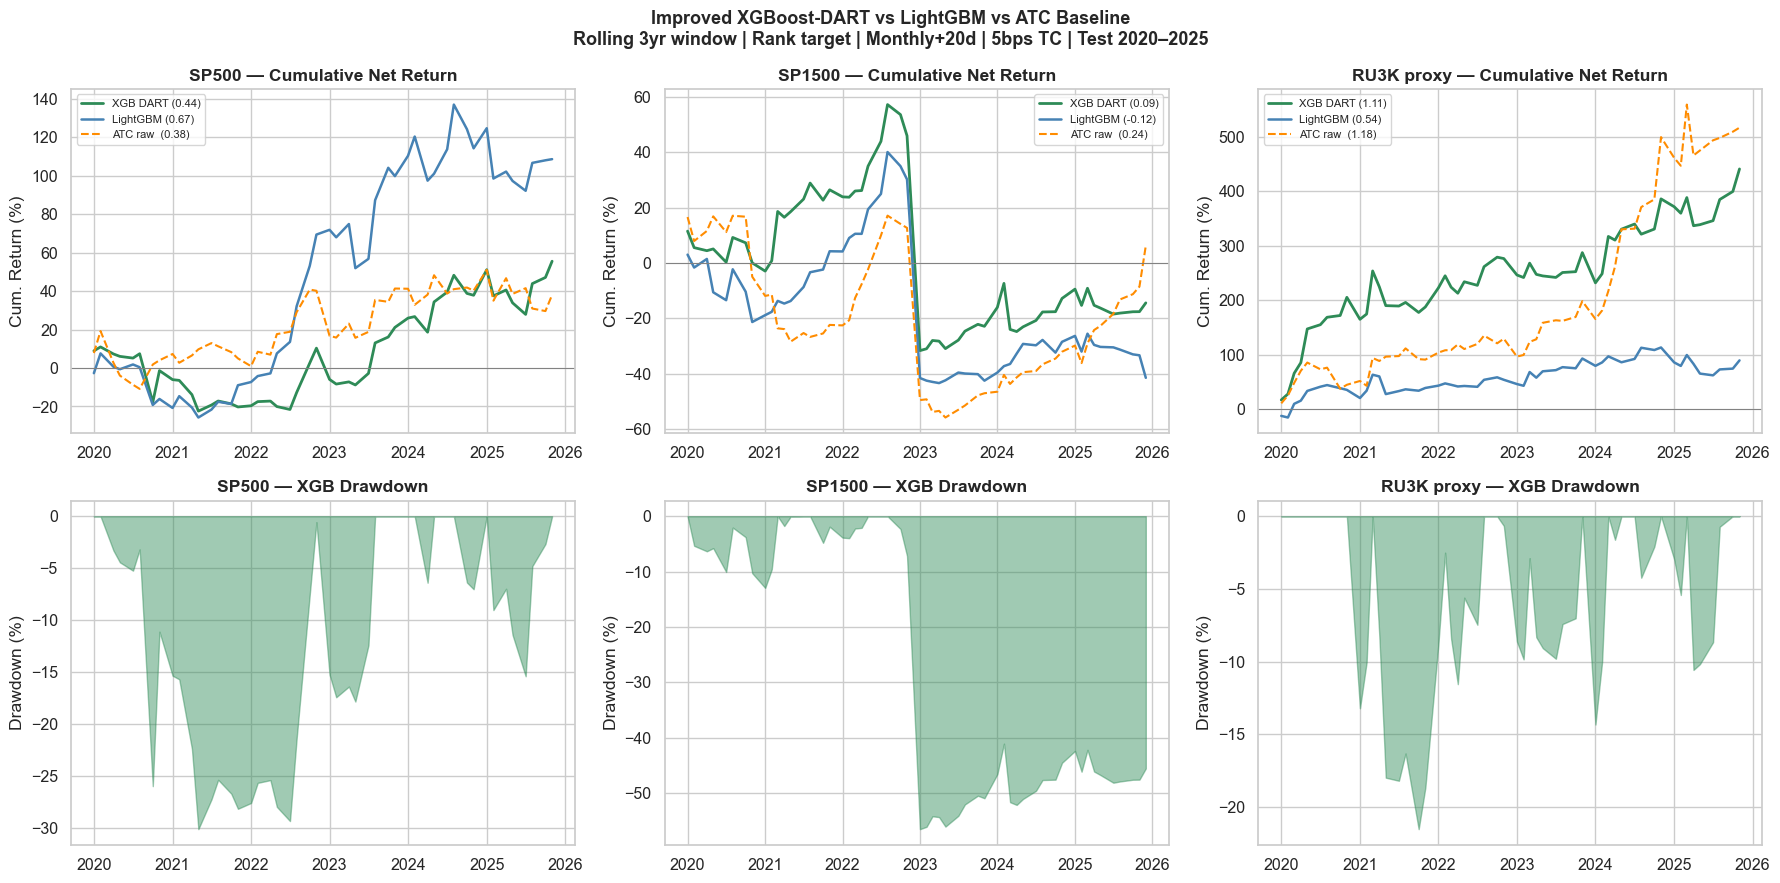

Saved → figures/xgb_improved_equity.png


In [6]:
# Side-by-side equity curves: XGB vs LGBM vs ATC baseline
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for col_idx, (univ, label) in enumerate([('in_sp500','SP500'),('in_sp1500','SP1500'),('in_ru3k','RU3K proxy')]):
    sub_xgb  = preds_df[preds_df[univ]].copy()
    sub_lgbm = lgbm_df[lgbm_df[univ]].copy() if 'lgbm_rank_pred' in lgbm_df.columns else sub_xgb

    try:
        r_xgb,  _ = simulate_portfolio(sub_xgb,  'xgb_rank_pred',    univ, 'M', 20)
        r_lgbm, _ = simulate_portfolio(sub_lgbm, 'lgbm_rank_pred',   univ, 'M', 20)
        r_atc,  _ = simulate_portfolio(sub_xgb,  'ATCClassifierScore', univ, 'M', 20)

        n_x = len(r_xgb)
        sh_x = sharpe(r_xgb['net_ls'],  n_x, n_years)
        sh_l = sharpe(r_lgbm['net_ls'], len(r_lgbm), n_years)
        sh_a = sharpe(r_atc['net_ls'],  len(r_atc),  n_years)

        ax = axes[0, col_idx]
        ax.plot(r_xgb.index.to_timestamp(),  (1+r_xgb['net_ls']).cumprod()*100-100,
                color='seagreen',   lw=2,   label=f'XGB DART ({sh_x:.2f})')
        ax.plot(r_lgbm.index.to_timestamp(), (1+r_lgbm['net_ls']).cumprod()*100-100,
                color='steelblue',  lw=1.8, label=f'LightGBM ({sh_l:.2f})')
        ax.plot(r_atc.index.to_timestamp(),  (1+r_atc['net_ls']).cumprod()*100-100,
                color='darkorange', lw=1.5, label=f'ATC raw  ({sh_a:.2f})', ls='--')
        ax.axhline(0, color='grey', lw=0.7)
        ax.set_title(f'{label} — Cumulative Net Return', fontweight='bold')
        ax.set_ylabel('Cum. Return (%)')
        ax.legend(fontsize=8)

        ax2 = axes[1, col_idx]
        cumval = 1 + (1+r_xgb['net_ls']).cumprod() - 1
        peak   = (1+r_xgb['net_ls']).cumprod().expanding().max()
        dd     = ((1+r_xgb['net_ls']).cumprod() / peak - 1) * 100
        ax2.fill_between(r_xgb.index.to_timestamp(), 0, dd, color='seagreen', alpha=0.45)
        ax2.set_title(f'{label} — XGB Drawdown', fontweight='bold')
        ax2.set_ylabel('Drawdown (%)')
    except Exception as e:
        axes[0, col_idx].text(0.5, 0.5, str(e), transform=axes[0, col_idx].transAxes, ha='center')

fig.suptitle('Improved XGBoost-DART vs LightGBM vs ATC Baseline\n'
             'Rolling 3yr window | Rank target | Monthly+20d | 5bps TC | Test 2020–2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'xgb_improved_equity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/xgb_improved_equity.png')

=== Year-by-year IC vs fwd_20d — SP500 ===
  2020: XGB=-0.0776  LGBM=-0.0123  ATC=-0.0950
  2021: XGB=+0.0506  LGBM=+0.0681  ATC=-0.0188
  2022: XGB=+0.0587  LGBM=+0.0543  ATC=+0.0375
  2023: XGB=+0.0079  LGBM=+0.0197  ATC=+0.0395
  2024: XGB=+0.1081  LGBM=+0.0748  ATC=+0.0346
  2025: XGB=-0.0147  LGBM=-0.0063  ATC=-0.0456


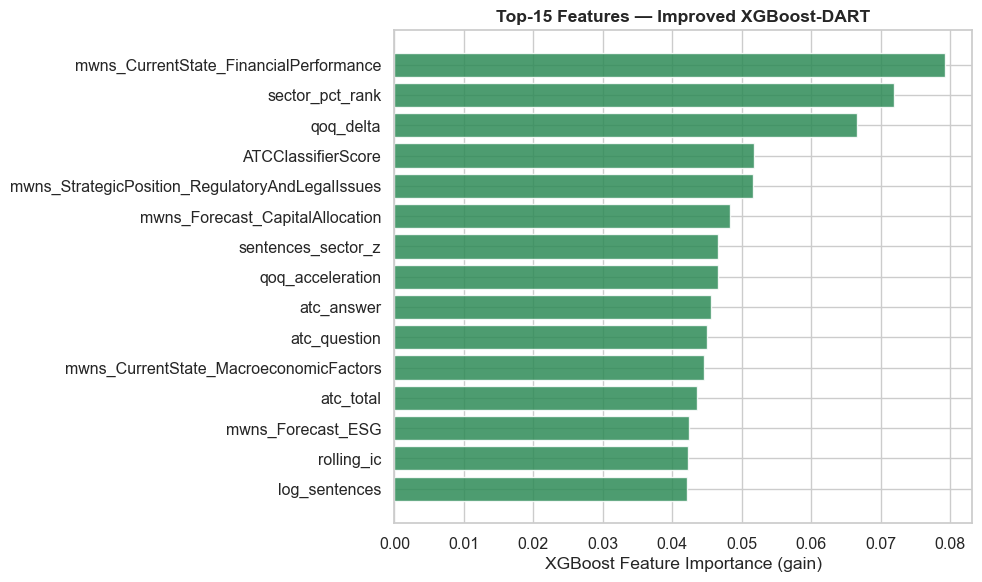

Saved → figures/xgb_improved_feature_importance.png

Top 10:
                                        feature  importance
         mwns_CurrentState_FinancialPerformance    0.079182
                                sector_pct_rank    0.071842
                                      qoq_delta    0.066632
                             ATCClassifierScore    0.051716
mwns_StrategicPosition_RegulatoryAndLegalIssues    0.051635
                mwns_Forecast_CapitalAllocation    0.048306
                             sentences_sector_z    0.046597
                               qoq_acceleration    0.046526
                                     atc_answer    0.045537
                                   atc_question    0.044989


In [7]:
# Year-by-year IC comparison
print('=== Year-by-year IC vs fwd_20d — SP500 ===')
sp = preds_df[preds_df['in_sp500']].dropna(subset=['fwd_20d'])
sp_l = lgbm_df[lgbm_df['in_sp500']].dropna(subset=['fwd_20d']) if 'lgbm_rank_pred' in lgbm_df.columns else None

for yr, grp in sp.groupby(sp['entry_date'].dt.year):
    ic_xgb = grp['xgb_rank_pred'].corr(grp['fwd_20d'],    method='spearman')
    ic_atc = grp['ATCClassifierScore'].corr(grp['fwd_20d'], method='spearman')
    ic_lgbm = np.nan
    if sp_l is not None:
        lg = sp_l[sp_l['entry_date'].dt.year == yr]
        if len(lg) > 10:
            ic_lgbm = lg['lgbm_rank_pred'].corr(lg['fwd_20d'], method='spearman')
    print(f'  {yr}: XGB={ic_xgb:+.4f}  LGBM={ic_lgbm:+.4f}  ATC={ic_atc:+.4f}')

# Feature importance
model_last = xgb.XGBRegressor(**XGB_PARAMS)
fi_train = feat_df[
    (feat_df['entry_date'] >= '2017-01-01') &
    (feat_df['entry_date'] <= '2019-12-31')
].dropna(subset=TOP_FEATS_FINAL + [TARGET_COL])
model_last.fit(fi_train[TOP_FEATS_FINAL].fillna(0), fi_train[TARGET_COL], verbose=False)

imp = pd.DataFrame({'feature': TOP_FEATS_FINAL,
                     'importance': model_last.feature_importances_}).sort_values('importance', ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp['feature'][:15], imp['importance'][:15], color='seagreen', alpha=0.85)
ax.set_xlabel('XGBoost Feature Importance (gain)')
ax.set_title('Top-15 Features — Improved XGBoost-DART', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / 'xgb_improved_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/xgb_improved_feature_importance.png')
print('\nTop 10:')
print(imp.head(10).to_string(index=False))

In [8]:
print('=== FINAL MODEL COMPARISON (all models, test period 2020-2025) ===')
print()
print(f'{"Universe":12s}  {"NB05 LGBM":12s}  {"NB08 XGB":10s}  '
      f'{"NB09 LGBM+":12s}  {"NB10 XGB+":10s}  {"ATC base":8s}')
print('-'*72)

# Load old NB05/NB08 results for comparison
nb05 = {'SP500': -0.538, 'SP1500': -0.243, 'RU3K proxy': 0.106}
nb08 = {'SP500':  0.091, 'SP1500':  0.522, 'RU3K proxy': -0.372}

nb09 = pd.read_csv(DATA_DIR / 'lgbm_improved_results.csv').set_index('Universe')
nb10 = res_df.set_index('Universe')

for label in ['SP500', 'SP1500', 'RU3K proxy']:
    v05  = nb05.get(label, np.nan)
    v08  = nb08.get(label, np.nan)
    v09  = nb09.loc[label, 'Improved LGBM (M+20d)'] if label in nb09.index else np.nan
    v10  = nb10.loc[label, 'Improved XGB (NB10)']  if label in nb10.index else np.nan
    vatc = nb10.loc[label, 'Baseline ATC']          if label in nb10.index else np.nan
    print(f'{label:12s}  {v05:+.3f}        {v08:+.3f}      {v09:+.3f}        {v10:+.3f}      {vatc:+.3f}')

print()
print('Note: NB09/NB10 use rolling window + rank target + monthly rebalance')
print('      NB05/NB08 used expanding window + raw return target + weekly/monthly')

=== FINAL MODEL COMPARISON (all models, test period 2020-2025) ===

Universe      NB05 LGBM     NB08 XGB    NB09 LGBM+    NB10 XGB+   ATC base
------------------------------------------------------------------------
SP500         -0.538        +0.091      +0.670        +0.439      +0.378
SP1500        -0.243        +0.522      -0.123        +0.095      +0.238
RU3K proxy    +0.106        -0.372      +0.540        +1.108      +1.177

Note: NB09/NB10 use rolling window + rank target + monthly rebalance
      NB05/NB08 used expanding window + raw return target + weekly/monthly
